# `prepare_one` — qstack-MLIR end-to-end demo

This notebook mirrors the legacy `examples/0.bell.ipynb` workflow on the
new MLIR stack: a `%%qasm` cell magic parses + lowers the surface
language to a `qstack` `ModuleOp`, and a `Machine` runs shots that come
back wrapped in a `Results` object with `plot_histogram()`.


In [1]:
%load_ext qstack.jupyter

In [2]:
%%qasm
QSTACKQASM 0.1;
include "qstack/cliffords.inc";

extern selector repeat_until_one(bit) -> int;

def prepare_one(qubit q) {
  qreg ancilla[1];
  bit m;
  h q;
  cx q, ancilla[0];
  measure ancilla[0] -> m;
  switch (repeat_until_one(m)) {
    case 0: { }
    case 1: { prepare_one q; }
  }
}

qreg q[1];
creg c[1];
prepare_one q[0];
measure q[0] -> c[0];

<ModuleOp 4431674400(operands=[], results=[], successors=[], properties={}, attributes={}, regions=[<Region 4431659088>], parent=None, _next_op=None, _prev_op=None)>

In [3]:
print(module)

builtin.module {
  func.func private @repeat_until_one(!qstack.bit) -> () attributes {qstack.selector}
  func.func @__case_0_1(%0: !qstack.qubit) -> !qstack.qubit {
    func.return %0 : !qstack.qubit
  }
  func.func @__case_1_2(%0: !qstack.qubit) -> !qstack.qubit {
    %1 = func.call @prepare_one(%0) : (!qstack.qubit) -> !qstack.qubit
    func.return %1 : !qstack.qubit
  }
  func.func @prepare_one(%0: !qstack.qubit) -> !qstack.qubit {
    %1, %2 = qstack.kernel {
    ^bb0(%3: !qstack.qubit):
      %4 = "cliffords.h"(%0) : (!qstack.qubit) -> !qstack.qubit
      %5, %6 = "cliffords.cx"(%4, %3) : (!qstack.qubit, !qstack.qubit) -> (!qstack.qubit, !qstack.qubit)
      %7 = qstack.measure %6
      qstack.return %7, %5 : !qstack.bit, !qstack.qubit
    } : () -> !qstack.bit, !qstack.qubit
    %8 = "qstack.select"(%1) <{callee = @repeat_until_one, bit_names = ["b0"], continuations = {"0" = @__case_0_1, "1" = @__case_1_2}}> : (!qstack.bit) -> ((!qstack.qubit) -> !qstack.qubit)
    %9 = "qstack.i

In [4]:
from qstack.runtime import CallbackRegistry, Machine

reg = CallbackRegistry()

@reg.selector("repeat_until_one")
def _pick(*, b0):
    # case 0 -> done, case 1 -> retry
    return "0" if b0 == 1 else "1"

machine = Machine(module, num_qubits=4, registry=reg)
results = machine.eval(shots=1000)
results

Results(1000 shots, histogram={(1,): 1000})

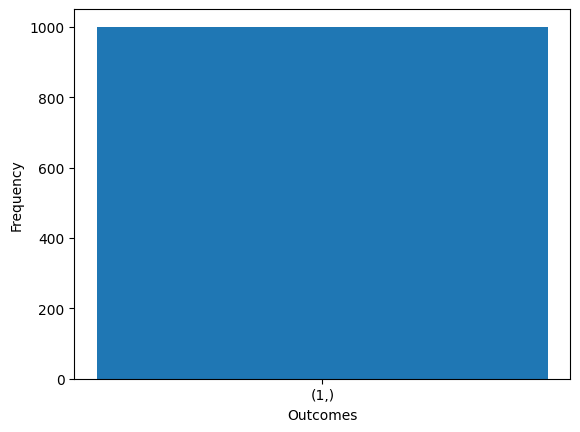

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [5]:
results.plot_histogram()